## Plotting different regimes

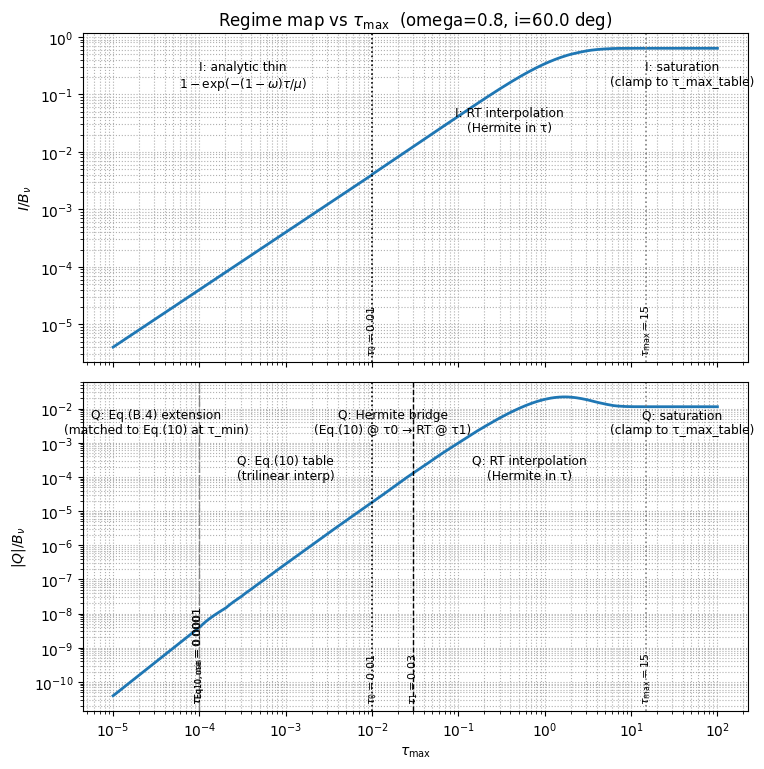

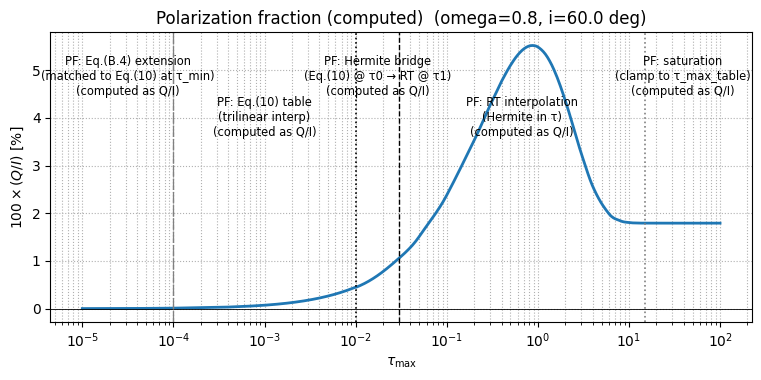

In [3]:
from emergentintensity import emergent_stokes, INTERP_TABLES, Q_THIN_TABLE

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Regime-map plotting script for the updated I/Q-only pipeline
#   - emergent_stokes(tau, omega, inc) -> (I, Q)  (patched)
#   - interpolate_stokes(tau, omega, inc) -> (I, Q) (pure RT interp)
#   - PF is computed as Q/I (no PF tables)
#
# IMPORTANT UPDATE (requested):
#   - Regime maps are DIFFERENT for Stokes I and Stokes Q.
#       * I regimes are defined by how emergent_stokes constructs I:
#           tau <= 0               : 0
#           omega == 0             : analytic absorption (same formula as thin I with omega=0)
#           tau < tau_min_table    : analytic_thin_I_scalar
#           tau >= tau_min_table   : RT interpolation (with saturation above tau_max_table)
#
#       * Q regimes are defined by how emergent_stokes constructs Q:
#           tau <= 0               : 0
#           omega == 0             : 0
#           tau < tau_min_table    : Eq10-table / B4 / fallback thin
#           tau_min_table..tau_1   : bridge (Eq10->RT or thin->RT)
#           tau_1..tau_max_table   : RT interpolation
#           tau > tau_max_table    : saturation
#
#   - PF uses Q-based regimes (allowed).
# ============================================================

# =========================
# User parameters
# =========================
omega0 = 0.8
inc0   = 60.0

# tau range for figure
tau_vals = np.logspace(-5, 2, 600)  # 1e-5 ... 1e2

# =========================
# Ensure tables loaded
# =========================
if INTERP_TABLES is None:
    setup_tables()

tau_grid      = np.asarray(INTERP_TABLES["tau_grid"], dtype=float)
tau_min_table = float(tau_grid[0])   # e.g. 0.01
tau_1         = float(tau_grid[1])   # e.g. 0.03
tau_max_table = float(tau_grid[-1])

has_eq10 = (Q_THIN_TABLE is not None)

# Eq10 tau-grid range (if present)
if has_eq10:
    tau_grid_thin = np.asarray(Q_THIN_TABLE["tau_grid"], dtype=float)
    tau_min_thin  = float(tau_grid_thin[0])
    tau_max_thin  = float(tau_grid_thin[-1])  # often ~ tau_min_table
else:
    tau_min_thin  = None
    tau_max_thin  = None

# TAU_EQ10_USE_MIN must exist in the updated full code
# If not, define a default consistent with the intended behavior.
try:
    _ = float(TAU_EQ10_USE_MIN)
except NameError:
    TAU_EQ10_USE_MIN = 1e-4


# =========================
# Compute curves (patched)
# =========================
I_arr  = np.empty_like(tau_vals, dtype=float)
Q_arr  = np.empty_like(tau_vals, dtype=float)
PF_arr = np.empty_like(tau_vals, dtype=float)

for i, t in enumerate(tau_vals):
    I, Q = emergent_stokes(float(t), float(omega0), float(inc0))
    I = float(I)
    Q = float(Q)
    I_arr[i] = I
    Q_arr[i] = Q
    PF_arr[i] = 0.0 if I == 0.0 else (Q / I)

# For loglog of Q, use absolute value (Q can be negative)
Qabs_arr = np.abs(Q_arr)
Qabs_arr = np.clip(Qabs_arr, 1e-300, None)

# For loglog of I, avoid log(0)
Iclip_arr = np.clip(I_arr, 1e-300, None)


# =========================
# Helpers
# =========================
def _geom_mid(a, b):
    a = float(a); b = float(b)
    return 10.0 ** (0.5 * (np.log10(a) + np.log10(b)))

def _place_region_text(ax, x0, x1, text, yfrac=0.90, fontsize=9):
    xmid = _geom_mid(x0, x1)
    ax.text(
        xmid, yfrac, text,
        transform=ax.get_xaxis_transform(),  # x in data, y in axes fraction
        ha="center", va="top", fontsize=fontsize
    )

def _vline(ax, x, label=None, **kw):
    ax.axvline(x, **kw)
    if label is not None:
        ax.text(
            x, 0.02, label,
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=8, rotation=90
        )

def _in_range(x, xmin, xmax):
    return (x is not None) and (xmin < float(x) < xmax)


# =========================
# Build regime boundaries separately
# =========================
xmin = float(tau_vals.min())
xmax = float(tau_vals.max())

# --- I boundaries (I uses analytic thin below tau_min_table; no Eq10 involvement) ---
bounds_I = [xmin, float(tau_min_table), float(tau_max_table), xmax]
bounds_I = sorted(set([float(np.clip(b, xmin, xmax)) for b in bounds_I]))
if bounds_I[0] != xmin:
    bounds_I = [xmin] + bounds_I
if bounds_I[-1] != xmax:
    bounds_I = bounds_I + [xmax]

# --- Q boundaries (Q uses Eq10/B4 below tau_min_table; and bridge in [tau_min_table, tau_1]) ---
bounds_Q = [xmin]

# Eq10 hard-use min boundary (requested) and Eq10 table min (optional)
if has_eq10 and _in_range(float(TAU_EQ10_USE_MIN), xmin, xmax):
    bounds_Q.append(float(TAU_EQ10_USE_MIN))
if has_eq10 and _in_range(tau_min_thin, xmin, xmax):
    bounds_Q.append(float(tau_min_thin))

# RT boundaries
bounds_Q.append(float(tau_min_table))
bounds_Q.append(float(tau_1))
bounds_Q.append(float(tau_max_table))
bounds_Q.append(xmax)

bounds_Q = sorted(set([float(np.clip(b, xmin, xmax)) for b in bounds_Q]))
if bounds_Q[0] != xmin:
    bounds_Q = [xmin] + bounds_Q
if bounds_Q[-1] != xmax:
    bounds_Q = bounds_Q + [xmax]


# =========================
# Region labels
# =========================
# --- I labels (correct, independent of Q) ---
region_labels_I = []
for j in range(len(bounds_I) - 1):
    a, b = bounds_I[j], bounds_I[j + 1]
    tm = _geom_mid(a, b)

    if tm < tau_min_table:
        region_labels_I.append(
            "I: analytic thin\n"
            r"$1-\exp(-(1-\omega)\tau/\mu)$"
        )
    elif tm <= tau_max_table:
        region_labels_I.append("I: RT interpolation\n(Hermite in τ)")
    else:
        region_labels_I.append("I: saturation\n(clamp to τ_max_table)")

# --- Q labels (updated logic) ---
region_labels_Q = []
for j in range(len(bounds_Q) - 1):
    a, b = bounds_Q[j], bounds_Q[j + 1]
    tm = _geom_mid(a, b)

    if tm < tau_min_table:
        if has_eq10:
            if tm < float(TAU_EQ10_USE_MIN):
                region_labels_Q.append("Q: Eq.(B.4) extension\n(matched to Eq.(10) at τ_min)")
            else:
                region_labels_Q.append("Q: Eq.(10) table\n(trilinear interp)")
        else:
            region_labels_Q.append("Q: thin approx ∝ τ²\n(matched to RT at τ_min)")
    elif tau_min_table <= tm <= tau_1:
        if has_eq10:
            region_labels_Q.append("Q: Hermite bridge\n(Eq.(10) @ τ0 → RT @ τ1)")
        else:
            region_labels_Q.append("Q: Hermite bridge\n(thin → RT)")
    elif tau_1 < tm <= tau_max_table:
        region_labels_Q.append("Q: RT interpolation\n(Hermite in τ)")
    else:
        region_labels_Q.append("Q: saturation\n(clamp to τ_max_table)")

# --- PF labels (allowed to reuse Q regimes) ---
region_labels_PF = [txt.replace("Q:", "PF:") + "\n(computed as Q/I)" for txt in region_labels_Q]


# =========================
# Plot: I and Q (loglog)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(7.8, 7.8), sharex=True)
axI, axQ = axes

axI.loglog(tau_vals, Iclip_arr, lw=2)
axI.set_ylabel(r"$I/B_\nu$")
axI.set_title(fr"Regime map vs $\tau_{{\max}}$  (omega={omega0}, i={inc0} deg)")
axI.grid(True, which="both", ls=":")

axQ.loglog(tau_vals, Qabs_arr, lw=2)
axQ.set_ylabel(r"$|Q|/B_\nu$")
axQ.set_xlabel(r"$\tau_{\max}$")
axQ.grid(True, which="both", ls=":")

# --- boundary lines for I panel (I-specific) ---
_vline(axI, tau_min_table, label=fr"$\tau_0={tau_min_table:g}$", color="k", ls=":",  lw=1.2)
_vline(axI, tau_max_table, label=fr"$\tau_{{\max}}={tau_max_table:g}$", color="gray", ls=":", lw=1.2)

# --- boundary lines for Q panel (Q-specific) ---
if has_eq10 and _in_range(float(TAU_EQ10_USE_MIN), xmin, xmax):
    _vline(axQ, float(TAU_EQ10_USE_MIN),
           label=fr"$\tau_{{\rm Eq10,use}}={float(TAU_EQ10_USE_MIN):g}$",
           color="gray", ls="-.", lw=0.9)

if has_eq10 and _in_range(tau_min_thin, xmin, xmax):
    _vline(axQ, float(tau_min_thin),
           label=fr"$\tau_{{\rm Eq10,min}}={tau_min_thin:g}$",
           color="gray", ls="--", lw=0.9)

_vline(axQ, tau_min_table, label=fr"$\tau_0={tau_min_table:g}$", color="k", ls=":",  lw=1.2)
_vline(axQ, tau_1,         label=fr"$\tau_1={tau_1:g}$",         color="k", ls="--", lw=1.0)
_vline(axQ, tau_max_table, label=fr"$\tau_{{\max}}={tau_max_table:g}$", color="gray", ls=":", lw=1.2)

# --- region texts: I panel uses bounds_I; Q panel uses bounds_Q ---
for j in range(len(bounds_I) - 1):
    a, b = bounds_I[j], bounds_I[j + 1]
    yI = 0.92 if (j % 2 == 0) else 0.78
    _place_region_text(axI, a, b, region_labels_I[j], yfrac=yI, fontsize=8.8)

for j in range(len(bounds_Q) - 1):
    a, b = bounds_Q[j], bounds_Q[j + 1]
    yQ = 0.92 if (j % 2 == 0) else 0.78
    _place_region_text(axQ, a, b, region_labels_Q[j], yfrac=yQ, fontsize=8.8)

plt.tight_layout()


# =========================
# Plot: PF = Q/I (semilogx), using Q-based regime split
# =========================
fig2 = plt.figure(figsize=(7.8, 3.9))
axP = plt.gca()

axP.semilogx(tau_vals, 100.0 * PF_arr, lw=2)
axP.axhline(0.0, color="k", lw=0.6)
axP.grid(True, which="both", ls=":")
axP.set_xlabel(r"$\tau_{\max}$")
axP.set_ylabel(r"$100\times(Q/I)$ [%]")
axP.set_title(fr"Polarization fraction (computed)  (omega={omega0}, i={inc0} deg)")

# Q-based boundary lines (no labels to reduce clutter)
if has_eq10 and _in_range(float(TAU_EQ10_USE_MIN), xmin, xmax):
    _vline(axP, float(TAU_EQ10_USE_MIN), label=None, color="gray", ls="-.", lw=0.9)

if has_eq10 and _in_range(tau_min_thin, xmin, xmax):
    _vline(axP, float(tau_min_thin), label=None, color="gray", ls="--", lw=0.9)

_vline(axP, tau_min_table, label=None, color="k",    ls=":",  lw=1.2)
_vline(axP, tau_1,         label=None, color="k",    ls="--", lw=1.0)
_vline(axP, tau_max_table, label=None, color="gray", ls=":",  lw=1.2)

# region text (Q-based)
for j in range(len(bounds_Q) - 1):
    a, b = bounds_Q[j], bounds_Q[j + 1]
    yP = 0.92 if (j % 2 == 0) else 0.78
    _place_region_text(axP, a, b, region_labels_PF[j], yfrac=yP, fontsize=8.3)

plt.tight_layout()